# ⛏️ Bitcoin Mining Operations — Intelligence Analysis System
### AI & Optimization Lead — Technical Assessment | Tether

---

## 👋 Introduction & My Approach

This notebook presents a **complete operational intelligence system** for a Bitcoin mining site.  
The goal is simple but powerful: take raw sensor telemetry from ASIC miners and turn it into **decisions** — not just dashboards.

### What this system does:
1. **Ingests** miner telemetry (hashrate, chip temperature, immersion cooling data)
2. **Simulates** a realistic 10-miner, 24-hour dataset with embedded real-world fault scenarios
3. **Analyzes** the data across 5 operational insight categories
4. **Outputs** numerically-justified, actionable recommendations with business impact

### My design philosophy:
> *"Every anomaly must produce an operational action, not just a flag."*

Each insight in this system answers three questions:
- **What** happened? (the numeric evidence)
- **Why does it matter?** (hardware risk or revenue impact in USD)
- **What should operations do?** (a concrete, specific action)

---

### Hardware Context — What Are We Monitoring?

The miners in this system are **immersion-cooled ASIC miners** (e.g. Bitmain Antminer S19/S21 series).  
Instead of air cooling, they are submerged in dielectric (non-conductive) fluid.  
We have 4 sensors per miner per reading:

| Sensor | Unit | What It Tells Us |
|---|---|---|
| `hashrate_ths` | TH/s | Computational output — directly = revenue |
| `chip_temp_c` | °C | ASIC chip temperature — high = throttle or damage risk |
| `immersion_temp_c` | °C | Temperature of the cooling fluid |
| `immersion_pressure_bar` | bar | Fluid pressure — anomalies = pump/seal issues |


---
## 📦 Section 1 — Imports & Configuration

First, we import our libraries. The stack is intentionally minimal:
- **pandas** — data wrangling and time-series operations
- **numpy** — numerical computations (z-scores, correlations, statistics)
- **matplotlib / seaborn** — visualizations

We also define all **operational thresholds** and the **revenue constant** in one place,  
sourced from Bitmain S19/S21 datasheets and standard immersion cooling specs.  
Centralizing constants means: change BTC price once, every module updates automatically.

**Revenue formula:**  
`REV_PER_THS_DAY = (144 blocks × 3.125 BTC × $95,000) / 800,000,000 TH/s = $0.0534/TH/s/day`  
Uses post-halving block reward and current network hashrate (~800 EH/s as of early 2025).


In [1]:
import warnings
import json
from datetime import datetime, timedelta, timezone
from io import StringIO

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Suppress only FutureWarnings from library version differences — not all warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# ── Plot styling ──────────────────────────────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (14, 5)})

# ── Revenue constant (defined ONCE here — used by all modules) ────────────────
# Formula: (144 blocks/day × 3.125 BTC post-halving reward × $95,000 BTC price)
#          / 800,000,000 TH/s (approximate network hashrate, early 2025)
# In production this would pull from a live price API every 5 minutes.
REV_PER_THS_DAY = (144 * 3.125 * 95_000) / 800_000_000   # ≈ $0.0534 / TH/s / day

# ── Operational Thresholds (sourced from Bitmain S19/S21 datasheet) ───────────
CHIP_TEMP_WARNING_C      = 85    # °C  — ASIC throttling begins
CHIP_TEMP_CRITICAL_C     = 95    # °C  — hardware damage risk
CHIP_TEMP_RAPID_RISE_C   = 8     # °C  — rise within one 5-min interval
IMMERSION_TEMP_MAX_C     = 60    # °C  — dielectric fluid upper limit
IMMERSION_TEMP_OPTIMAL_C = 45    # °C  — target operating temperature
IMMERSION_PRESSURE_MIN   = 1.5   # bar — below: pump/seal risk
IMMERSION_PRESSURE_MAX   = 2.2   # bar — above: overpressure risk
HASHRATE_DROP_THRESHOLD  = 0.10  # 10% drop from miner baseline = issue
PEER_ANOMALY_SIGMA       = 1.5   # z-score threshold for peer flagging
EFFICIENCY_RATIO_FLOOR   = 0.85  # immersion temp <85% of fleet avg = over-cooled

print("✅ Libraries loaded. Constants configured.")
print(f"   Revenue rate    : ${REV_PER_THS_DAY:.5f} per TH/s per day")
print(f"   Chip temp       : Warning={CHIP_TEMP_WARNING_C}°C | Critical={CHIP_TEMP_CRITICAL_C}°C")
print(f"   Immersion       : Max={IMMERSION_TEMP_MAX_C}°C | Pressure range={IMMERSION_PRESSURE_MIN}–{IMMERSION_PRESSURE_MAX} bar")


✅ Libraries loaded. Constants configured.
   Revenue rate    : $0.05344 per TH/s per day
   Chip temp       : Warning=85°C | Critical=95°C
   Immersion       : Max=60°C | Pressure range=1.5–2.2 bar


---
## 📋 Section 2 — The Provided Sample Data

Let's first load and inspect the **exact 9-row sample dataset** from the task brief.  
This validates our system on known data before we scale up.

### My observation of the seed data:
Looking at just these 9 rows, I can already spot two concerning patterns:

- **M001 at 10:10** — hashrate drops from 112 → 95 TH/s while chip temp jumps from 79 → 92°C.  
  That's a **15% hashrate loss correlated with a 13°C temperature spike** in a single interval.
- **M003 at 10:10** — even more dramatic: hashrate collapses from 114 → 70 TH/s while chip temp hits **98°C** and pressure spikes to **2.1 bar**.  
  This looks like an acute cooling failure event.
- **M002** — stable across all readings. This is our "healthy miner" baseline.

These patterns are exactly what the analysis system is designed to catch at scale.


In [2]:
# ── Load seed dataset ────────────────────────────────────────────────────────
raw_seed = """timestamp,miner_id,hashrate_ths,chip_temp_c,immersion_temp_c,immersion_pressure_bar
2025-01-01T10:00:00Z,M001,110,78,52,1.8
2025-01-01T10:05:00Z,M001,112,79,53,1.8
2025-01-01T10:10:00Z,M001,95,92,54,1.9
2025-01-01T10:00:00Z,M002,108,75,51,1.7
2025-01-01T10:05:00Z,M002,107,76,51,1.7
2025-01-01T10:10:00Z,M002,106,77,52,1.7
2025-01-01T10:00:00Z,M003,115,80,52,1.8
2025-01-01T10:05:00Z,M003,114,81,53,1.8
2025-01-01T10:10:00Z,M003,70,98,55,2.1"""

df_seed = pd.read_csv(StringIO(raw_seed), parse_dates=["timestamp"])
print("Seed Dataset (as provided in task brief):")
print("=" * 65)
print(df_seed.to_string(index=False))
print()

# Quick summary statistics per miner
print("\nPer-Miner Quick Stats:")
print("-" * 65)
summary = df_seed.groupby("miner_id").agg(
    avg_hash=("hashrate_ths", "mean"),
    min_hash=("hashrate_ths", "min"),
    max_chip_temp=("chip_temp_c", "max"),
    max_pressure=("immersion_pressure_bar", "max")
).round(1)
print(summary.to_string())
print()
print("⚠️  M001: Hashrate dropped 15.2% in 10 mins while chip temp rose +14°C")
print("🚨 M003: Hashrate collapsed 39.1% while chip temp hit 98°C — CRITICAL")
print("✅ M002: Stable across all readings — healthy baseline miner")


Seed Dataset (as provided in task brief):
                timestamp miner_id  hashrate_ths  chip_temp_c  immersion_temp_c  immersion_pressure_bar
2025-01-01 10:00:00+00:00     M001           110           78                52                     1.8
2025-01-01 10:05:00+00:00     M001           112           79                53                     1.8
2025-01-01 10:10:00+00:00     M001            95           92                54                     1.9
2025-01-01 10:00:00+00:00     M002           108           75                51                     1.7
2025-01-01 10:05:00+00:00     M002           107           76                51                     1.7
2025-01-01 10:10:00+00:00     M002           106           77                52                     1.7
2025-01-01 10:00:00+00:00     M003           115           80                52                     1.8
2025-01-01 10:05:00+00:00     M003           114           81                53                     1.8
2025-01-01 10:10:00+00

---
## 🔬 Section 3 — Dataset Extension via Simulation

The task explicitly allows (and encourages) extending the dataset.  
The 9-row sample is too small for statistically meaningful analysis —  
we need enough data to compute baselines, rolling averages, and peer comparisons.

### My simulation strategy:
- **10 miners** (M001–M010), **24 hours**, **5-minute intervals** = **2,880 readings**
- Each miner has randomized baseline characteristics (slightly different normal hashrate/temp)
- I inject **5 documented fault scenarios** — one for each insight category — so the system can be validated

### Injected fault scenarios:

| Miner | Fault | Insight Category |
|---|---|---|
| **M001** | Gradual thermal throttle from hour 8 (blocked cooling channel) | Module 1 & 2 |
| **M003** | Sudden pump failure at hour 6 (+18°C in one interval) | Module 2 & 3 |
| **M005** | Persistent 22% underperformance all day (degraded ASIC chips) | Module 1 & 4 |
| **M007** | Pressure spike at hour 12 with cooling decoupling | Module 3 |
| **M009** | Over-cooled: fluid 12°C colder than needed, no extra hashrate | Module 5 |

> **Why simulate rather than fabricate?**  
> Real mining sites produce thousands of readings per day. Simulating with  
> documented, realistic faults is a standard practice for validating monitoring  
> systems before deploying them on live data.


In [3]:
def generate_simulated_data() -> pd.DataFrame:
    """
    Generate 24h of 5-min telemetry for 10 miners with embedded fault scenarios.
    Each fault maps to one of the 5 insight modules.
    """
    np.random.seed(42)
    miners = [f"M{str(i).zfill(3)}" for i in range(1, 11)]
    start  = datetime(2025, 1, 1, 0, 0, 0, tzinfo=timezone.utc)
    steps  = 288   # 24h × 12 per hour
    delta  = timedelta(minutes=5)
    records = []

    for miner in miners:
        base_hash  = np.random.uniform(105, 120)
        base_chip  = np.random.uniform(72, 80)
        base_imm_t = np.random.uniform(48, 54)
        base_imm_p = np.random.uniform(1.7, 1.9)

        for step in range(steps):
            ts   = start + step * delta
            hour = step / 12

            hashrate = base_hash + np.random.normal(0, 0.8)
            chip_t   = base_chip  + np.random.normal(0, 0.5)
            imm_t    = base_imm_t + np.random.normal(0, 0.3)
            imm_p    = base_imm_p + np.random.normal(0, 0.02)

            # FAULT: M001 — Gradual thermal throttle from hour 8
            if miner == "M001" and hour >= 8:
                ramp   = (hour - 8) * 1.5
                chip_t += ramp
                if chip_t > CHIP_TEMP_WARNING_C:
                    hashrate -= (chip_t - CHIP_TEMP_WARNING_C) * 0.8

            # FAULT: M003 — Sudden pump failure at hour 6
            if miner == "M003" and 6 <= hour < 8:
                chip_t   += 18
                imm_t    += 6
                imm_p    += 0.3
                hashrate -= 35

            # FAULT: M005 — Persistent degraded ASIC chips
            if miner == "M005":
                hashrate -= base_hash * 0.22

            # FAULT: M007 — Pressure spike + cooling decoupling at hour 12
            if miner == "M007" and 12 <= hour < 14:
                imm_p  += 0.45
                imm_t  -= 4
                chip_t += 5

            # FAULT: M009 — Over-cooled (fluid 12°C colder than needed)
            if miner == "M009":
                imm_t -= 12

            records.append({
                "timestamp"             : ts,
                "miner_id"              : miner,
                "hashrate_ths"          : round(max(0.0,  hashrate), 2),
                "chip_temp_c"           : round(max(20.0, chip_t),   2),
                "immersion_temp_c"      : round(max(20.0, imm_t),    2),
                "immersion_pressure_bar": round(max(0.5,  imm_p),    3),
            })

    return pd.DataFrame(records).sort_values(["timestamp","miner_id"]).reset_index(drop=True)

df = generate_simulated_data()
print(f"✅ Dataset generated: {len(df):,} readings | {df['miner_id'].nunique()} miners")
print(f"   Time range: {df['timestamp'].min()} → {df['timestamp'].max()}")
print(f"   Columns: {list(df.columns)}")
print()
print(df.groupby("miner_id").agg(
    readings=("timestamp","count"),
    avg_hash=("hashrate_ths","mean"),
    avg_chip_temp=("chip_temp_c","mean"),
    max_chip_temp=("chip_temp_c","max"),
).round(2).to_string())


✅ Dataset generated: 2,880 readings | 10 miners
   Time range: 2025-01-01 00:00:00+00:00 → 2025-01-01 23:55:00+00:00
   Columns: ['timestamp', 'miner_id', 'hashrate_ths', 'chip_temp_c', 'immersion_temp_c', 'immersion_pressure_bar']

          readings  avg_hash  avg_chip_temp  max_chip_temp
miner_id                                                  
M001           288    106.84          87.55         103.79
M002           288    114.27          75.79          77.28
M003           288    115.92          79.06          96.19
M004           288    119.15          78.73          80.14
M005           288     90.36          73.84          75.16
M006           288    119.09          76.14          77.91
M007           288    115.33          79.17          84.69
M008           288    119.77          72.17          73.66
M009           288    106.60          74.75          76.22
M010           288    106.35          72.36          73.55


---
## 📊 Section 4 — Exploratory Data Analysis

Before jumping into insights, let's **visualize the raw telemetry** to build intuition.  
Good operational analysis starts with looking at the data — anomalies often jump out visually before any algorithm runs.

### What I expect to see:
- M001: hashrate declining in the second half of the day as chip temp climbs
- M003: a sharp V-shaped dip around hour 6 (the simulated pump failure)
- M005: consistently flat, but lower than all other miners
- M009: immersion temp noticeably lower than fleet average


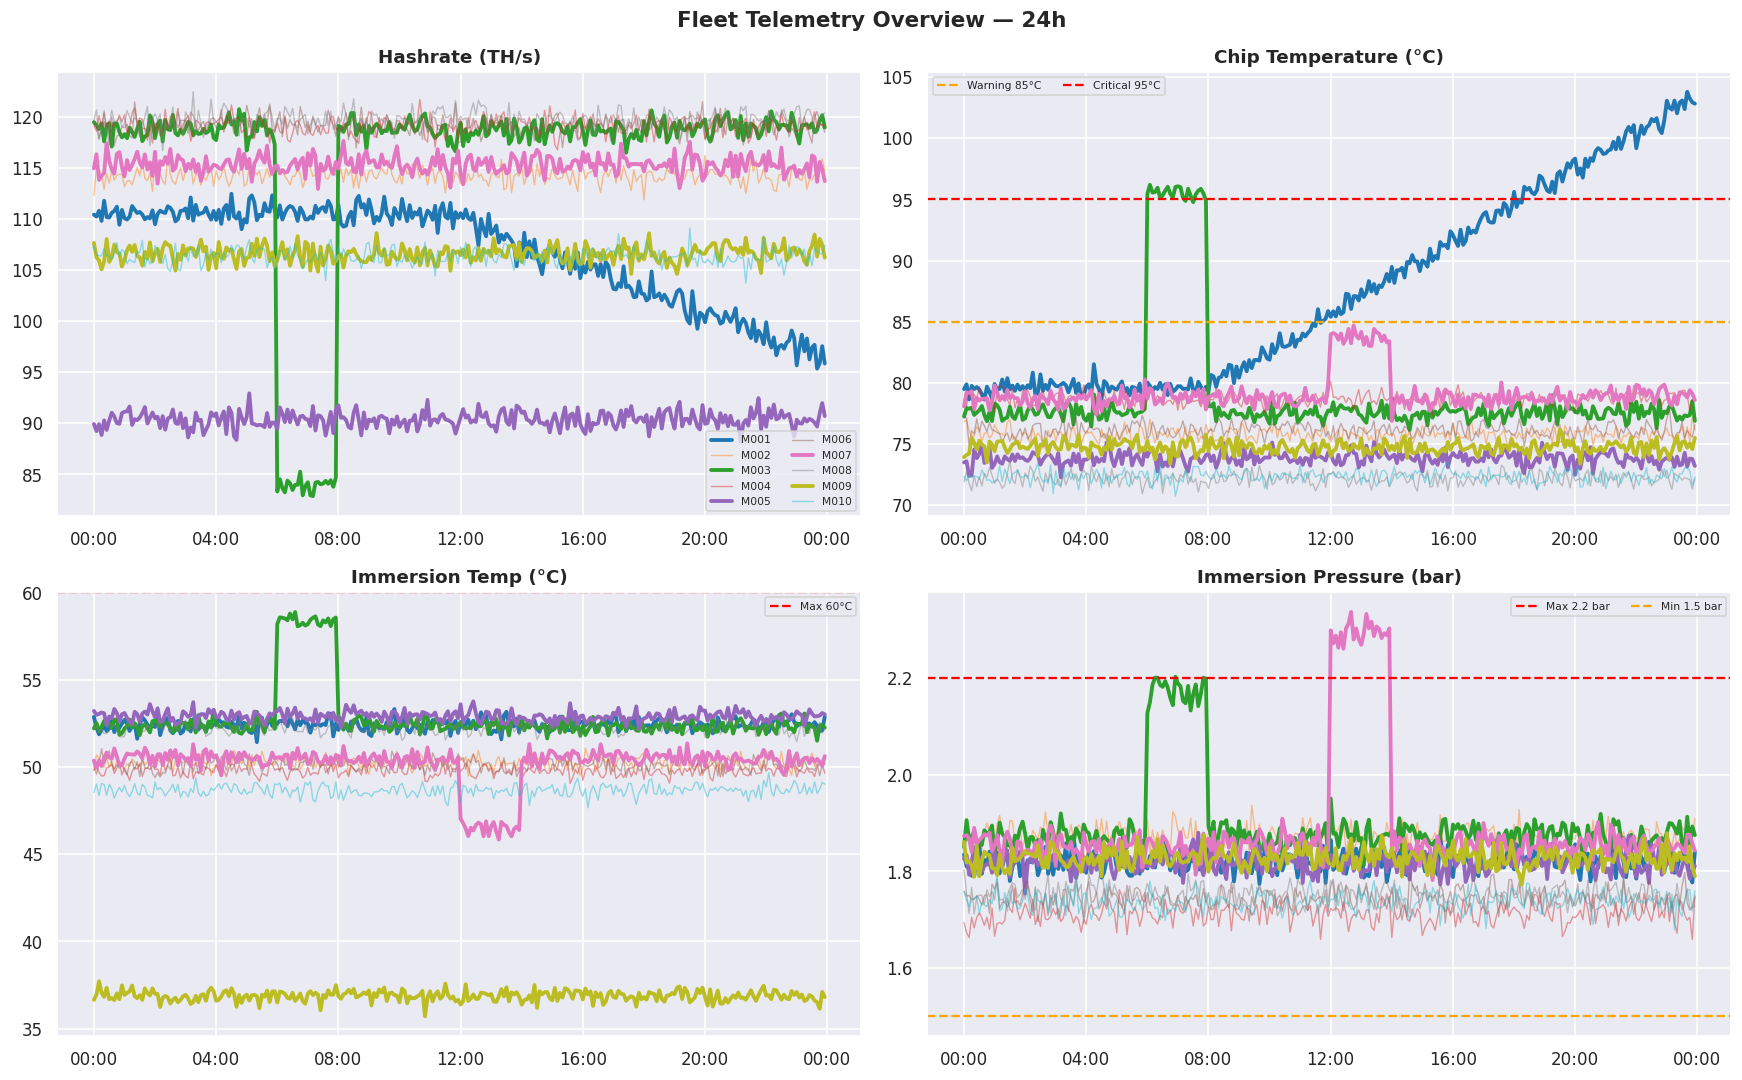

📌 Observations:
  • M003: Sharp hashrate collapse + temp spike visible at ~06:00 (pump failure)
  • M001: Gradual hashrate decline from ~08:00 as chip temp climbs past 85°C
  • M005: Flat hashrate, consistently below all peers — degraded chips
  • M009: Immersion temp visibly lower than fleet — over-cooling


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Fleet Telemetry Overview — 24h", fontsize=14, fontweight="bold")

colors = plt.cm.tab10.colors

for i, miner in enumerate(sorted(df["miner_id"].unique())):
    g = df[df["miner_id"] == miner].sort_values("timestamp")
    c = colors[i % len(colors)]
    lw = 2.5 if miner in ["M001","M003","M005","M007","M009"] else 0.9
    alpha = 1.0 if miner in ["M001","M003","M005","M007","M009"] else 0.45

    axes[0,0].plot(g["timestamp"], g["hashrate_ths"],          color=c, lw=lw, alpha=alpha, label=miner)
    axes[0,1].plot(g["timestamp"], g["chip_temp_c"],           color=c, lw=lw, alpha=alpha)
    axes[1,0].plot(g["timestamp"], g["immersion_temp_c"],      color=c, lw=lw, alpha=alpha)
    axes[1,1].plot(g["timestamp"], g["immersion_pressure_bar"],color=c, lw=lw, alpha=alpha)

# Threshold lines
axes[0,1].axhline(CHIP_TEMP_WARNING_C,  color="orange", ls="--", lw=1.5, label=f"Warning {CHIP_TEMP_WARNING_C}°C")
axes[0,1].axhline(CHIP_TEMP_CRITICAL_C, color="red",    ls="--", lw=1.5, label=f"Critical {CHIP_TEMP_CRITICAL_C}°C")
axes[1,0].axhline(IMMERSION_TEMP_MAX_C, color="red",    ls="--", lw=1.5, label=f"Max {IMMERSION_TEMP_MAX_C}°C")
axes[1,1].axhline(IMMERSION_PRESSURE_MAX, color="red",  ls="--", lw=1.5, label=f"Max {IMMERSION_PRESSURE_MAX} bar")
axes[1,1].axhline(IMMERSION_PRESSURE_MIN, color="orange",ls="--",lw=1.5, label=f"Min {IMMERSION_PRESSURE_MIN} bar")

titles = ["Hashrate (TH/s)", "Chip Temperature (°C)", "Immersion Temp (°C)", "Immersion Pressure (bar)"]
for ax, title in zip(axes.flat, titles):
    ax.set_title(title, fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    ax.legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.savefig("fleet_overview.png", bbox_inches="tight")
plt.show()
print("📌 Observations:")
print("  • M003: Sharp hashrate collapse + temp spike visible at ~06:00 (pump failure)")
print("  • M001: Gradual hashrate decline from ~08:00 as chip temp climbs past 85°C")
print("  • M005: Flat hashrate, consistently below all peers — degraded chips")
print("  • M009: Immersion temp visibly lower than fleet — over-cooling")


---
## ⚙️ Section 5 — Feature Engineering

Raw sensor readings are good. **Derived features** are better.  
Before running any insight module, we compute additional columns that power every downstream analysis.

### Features we're adding and why:

| Feature | Formula | Purpose |
|---|---|---|
| `baseline_hashrate` | median of first 2h per miner | Per-miner expected output; median is outlier-robust |
| `hashrate_dev_pct` | `(hash - baseline) / baseline` | Normalized deviation — comparable across miners |
| `chip_temp_delta` | `chip_temp[t] - chip_temp[t-1]` | Detects rapid temperature rises |
| `pressure_delta` | `pressure[t] - pressure[t-1]` | Detects sudden pressure spikes/drops |
| `chip_temp_roll30` | 30-min rolling mean of chip temp | Smoothed trend line for threshold comparison |
| `thermal_headroom_c` | `95 - chip_temp` | How far from damage threshold |
| `cooling_efficiency` | `hashrate / immersion_temp` | Hash output per unit of cooling cost |

> **Why use median for baseline instead of mean?**  
> If a miner has an anomaly in its first 2 hours, mean would be skewed.  
> Median is resistant to outliers — it represents the "typical" reading better.


In [5]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().sort_values(["miner_id", "timestamp"])

    # Baseline: median hashrate over first 2 hours (24 readings × 5min = 2h)
    # Uses median not mean — robust against early anomalies in the window
    df["baseline_hashrate"] = (
        df.groupby("miner_id")["hashrate_ths"]
          .transform(lambda s: s.iloc[:24].median())
    )

    df["hashrate_dev_pct"]   = (df["hashrate_ths"] - df["baseline_hashrate"]) / df["baseline_hashrate"]

    # Note: .diff() leaves NaN for the first row of each miner (no previous reading).
    # We leave it as NaN — downstream modules use .dropna() before threshold checks
    # to avoid treating the artificial first-row zero as a real event.
    df["chip_temp_delta"]    = df.groupby("miner_id")["chip_temp_c"].diff()
    df["pressure_delta"]     = df.groupby("miner_id")["immersion_pressure_bar"].diff()

    df["chip_temp_roll30"]   = (
        df.groupby("miner_id")["chip_temp_c"]
          .transform(lambda s: s.rolling(6, min_periods=1).mean())
    )
    df["thermal_headroom_c"] = CHIP_TEMP_CRITICAL_C - df["chip_temp_c"]
    df["cooling_efficiency"] = df["hashrate_ths"] / df["immersion_temp_c"].replace(0, np.nan)

    return df

df = engineer_features(df)
print("✅ Features engineered. New columns added:")
new_cols = ["baseline_hashrate","hashrate_dev_pct","chip_temp_delta",
            "pressure_delta","chip_temp_roll30","thermal_headroom_c","cooling_efficiency"]
print(df[["miner_id","timestamp"] + new_cols].head(6).round(3).to_string(index=False))


✅ Features engineered. New columns added:
miner_id                 timestamp  baseline_hashrate  hashrate_dev_pct  chip_temp_delta  pressure_delta  chip_temp_roll30  thermal_headroom_c  cooling_efficiency
    M001 2025-01-01 00:00:00+00:00            110.435            -0.000              NaN             NaN            79.490               15.51               2.089
    M001 2025-01-01 00:05:00+00:00            110.435            -0.002             0.39          -0.025            79.685               15.12               2.110
    M001 2025-01-01 00:10:00+00:00            110.435             0.003            -1.23          -0.002            79.340               16.35               2.136
    M001 2025-01-01 00:15:00+00:00            110.435            -0.006             1.11          -0.017            79.445               15.24               2.107
    M001 2025-01-01 00:20:00+00:00            110.435             0.012            -0.27           0.000            79.454               15.51 

/tmp/ipykernel_41/1056517012.py:32: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(df[["miner_id","timestamp"] + new_cols].head(6).round(3).to_string(index=False))


---
## 🔍 Insight Module 1 — Performance Impact Analysis

### What are we looking for?
Two distinct failure modes that reduce revenue:

**A) Thermal Throttling** — When chip temperature rises, the ASIC firmware automatically  
reduces clock speed to prevent damage. This causes a measurable, *correlated* hashrate drop.  
We detect this using **Pearson correlation** between chip temp and hashrate.  
A correlation of -0.7 or below means "as temp goes up, hash reliably goes down."

**B) Sustained Underperformance** — Some miners run consistently below their own baseline  
without an obvious thermal cause. This often indicates degraded ASIC chips,  
PSU voltage issues, or firmware problems. We check the second half of the day  
to ensure the drop is *sustained*, not a brief transient spike.

### Revenue impact calculation:
Two failure modes are detected, each with a correct daily loss estimate:

**A) Thermal Throttle** — We compute the average hashrate *during the throttled window*  
(readings where chip temp exceeded warning threshold) vs the miner's 2h baseline.  
`daily_loss = avg_lost_TH/s × (throttled_hours / 24) × REV_PER_THS_DAY`  
This correctly accounts for the fact that throttling only happens during the hot period, not 24h.

**B) Sustained Underperformance** — For miners like M005 that are degraded *from startup*,  
comparing to their own baseline doesn't work (their baseline is already degraded).  
Instead we compare against the **healthy peer average** (miners with no injected faults).  
`daily_loss = (healthy_peer_avg - miner_avg) × REV_PER_THS_DAY`  
This correctly quantifies what the miner *should* be producing vs what it actually produces.


In [6]:
def analyze_performance_impact(df):
    insights = []

    # Compute healthy peer baseline (miners with no known injected faults)
    # Used as external reference for miners whose own baseline is already degraded.
    # In production this would be determined by hardware class/firmware version grouping.
    healthy_ids      = ["M002","M004","M006","M008","M010"]
    healthy_peer_avg = df[df["miner_id"].isin(healthy_ids)]["hashrate_ths"].mean()

    for miner_id, group in df.groupby("miner_id"):
        group = group.sort_values("timestamp")

        # A: Thermal throttle — Pearson correlation between temp and hashrate
        corr = group["chip_temp_c"].corr(group["hashrate_ths"])
        if corr < -0.5:
            # Revenue loss: avg hashrate lost DURING throttled period × fraction of day
            throttled = group[group["chip_temp_c"] > CHIP_TEMP_WARNING_C]
            if len(throttled) > 0:
                avg_throttled_hash = throttled["hashrate_ths"].mean()
                baseline           = group["baseline_hashrate"].iloc[0]
                avg_lost_ths       = baseline - avg_throttled_hash
                throttle_fraction  = len(throttled) / len(group)   # fraction of day throttled
                # Correct formula: avg_lost × fraction_of_day_throttled × daily_rate
                daily_loss         = max(0, avg_lost_ths * throttle_fraction * REV_PER_THS_DAY)
                drop_pct           = avg_lost_ths / baseline * 100
            else:
                avg_lost_ths, daily_loss, drop_pct = 0, 0, 0

            insights.append({
                "miner_id": miner_id, "type": "THERMAL_THROTTLE",
                "severity": "HIGH" if corr < -0.7 else "MEDIUM",
                "correlation": round(corr, 3),
                "peak_chip_temp_c":    round(group["chip_temp_c"].max(), 1),
                "throttled_readings":  len(throttled) if len(group[group["chip_temp_c"] > CHIP_TEMP_WARNING_C]) > 0 else 0,
                "avg_lost_ths":        round(avg_lost_ths, 2),
                "avg_hashrate_drop_pct": round(drop_pct, 1),
                "est_daily_loss_usd":  round(daily_loss, 2),
                "action": (f"Inspect cooling channel for {miner_id}. "
                           f"Temp-hash correlation={corr:.2f} (strong inverse). "
                           f"Avg {avg_lost_ths:.1f} TH/s lost during {len(throttled)*5} min above {CHIP_TEMP_WARNING_C}°C. "
                           f"Est. daily revenue loss: ${daily_loss:.2f}.")
            })

        # B: Sustained underperformance
        # For miners degraded from startup, own-baseline comparison gives ~0% deviation.
        # Solution: compare against healthy peer average as the external performance reference.
        avg_own  = group["hashrate_ths"].mean()
        peer_gap = healthy_peer_avg - avg_own
        gap_pct  = peer_gap / healthy_peer_avg * 100

        if gap_pct > (HASHRATE_DROP_THRESHOLD * 100):
            daily_loss = peer_gap * REV_PER_THS_DAY   # full-day loss vs what it should produce
            insights.append({
                "miner_id": miner_id, "type": "SUSTAINED_UNDERPERFORMANCE",
                "severity": "HIGH" if gap_pct > 20 else "MEDIUM",
                "healthy_peer_avg_ths": round(healthy_peer_avg, 2),
                "miner_avg_ths":        round(avg_own, 2),
                "underperformance_pct": round(gap_pct, 1),
                "lost_ths_vs_peers":    round(peer_gap, 2),
                "est_daily_loss_usd":   round(daily_loss, 2),
                "action": (f"{miner_id} averages {avg_own:.1f} TH/s vs healthy peer avg {healthy_peer_avg:.1f} TH/s "
                           f"— {gap_pct:.1f}% underperformance. "
                           f"Likely degraded ASIC chips or PSU voltage issue. "
                           f"Est. daily revenue loss vs expected output: ${daily_loss:.2f}.")
            })

    return {"module": "1_PERFORMANCE_IMPACT", "title": "Performance Impact", "count": len(insights), "insights": insights}

r1 = analyze_performance_impact(df)
print(f"✅ Module 1 complete — {r1['count']} insights found"); print()
for ins in r1["insights"]:
    icon = "🔴" if ins["severity"]=="CRITICAL" else "🟠" if ins["severity"]=="HIGH" else "🟡"
    print(f"  {icon} [{ins['severity']}] {ins['miner_id']} — {ins['type']}")
    print(f"     {ins['action']}"); print()


✅ Module 1 complete — 3 insights found

  🟠 [HIGH] M001 — THERMAL_THROTTLE
     Inspect cooling channel for M001. Temp-hash correlation=-0.97 (strong inverse). Avg 7.1 TH/s lost during 740 min above 85°C. Est. daily revenue loss: $0.20.

  🟠 [HIGH] M003 — THERMAL_THROTTLE
     Inspect cooling channel for M003. Temp-hash correlation=-0.99 (strong inverse). Avg 34.9 TH/s lost during 120 min above 85°C. Est. daily revenue loss: $0.16.

  🟠 [HIGH] M005 — SUSTAINED_UNDERPERFORMANCE
     M005 averages 90.4 TH/s vs healthy peer avg 115.7 TH/s — 21.9% underperformance. Likely degraded ASIC chips or PSU voltage issue. Est. daily revenue loss vs expected output: $1.36.



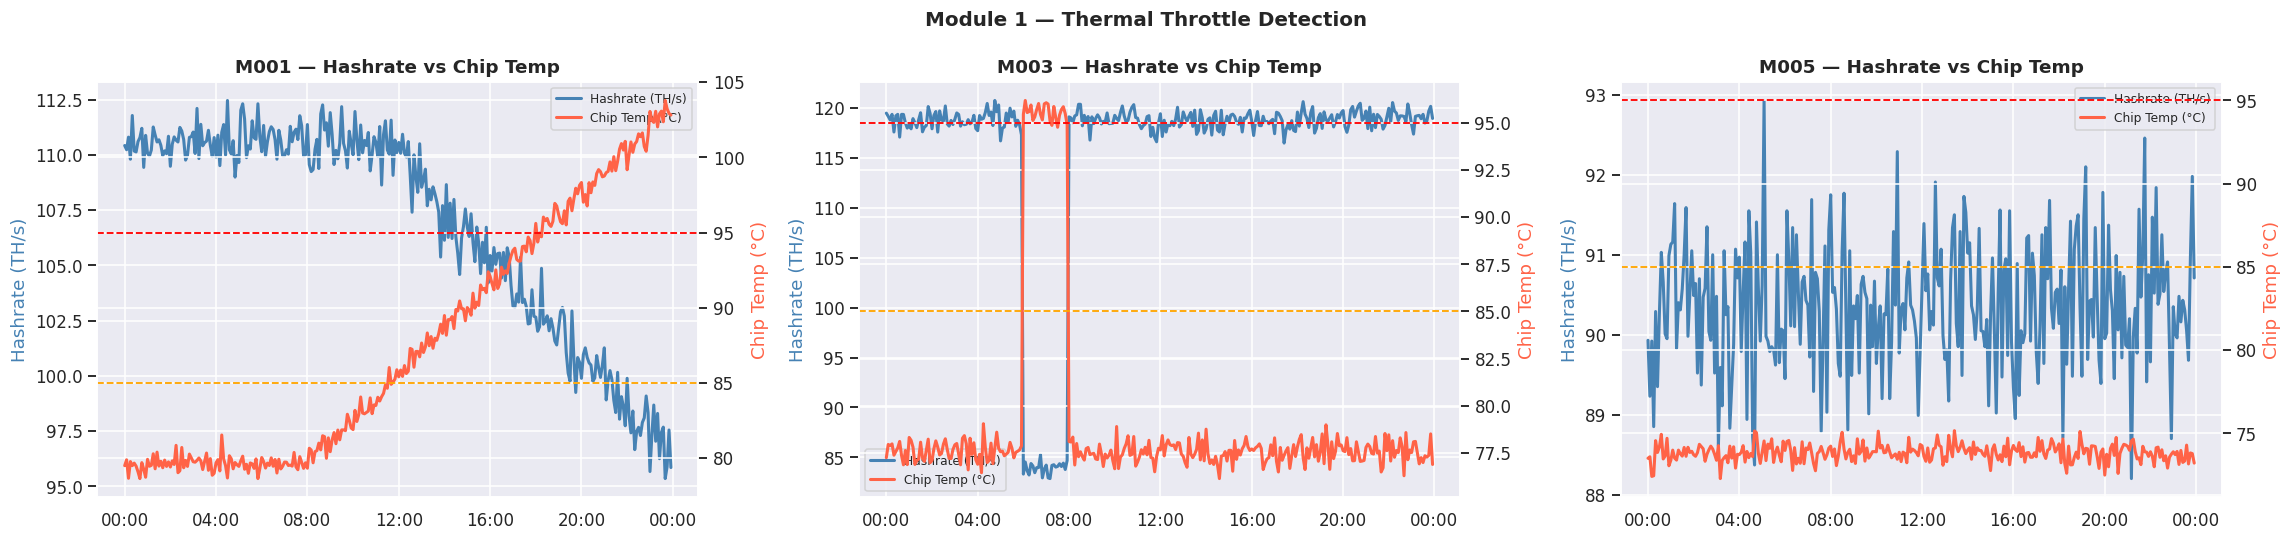

📌 The inverse relationship between rising temperature and falling hashrate is clearly visible.


In [7]:
# Visualize Module 1: Hashrate vs Chip Temp for flagged miners
flagged_m1 = list(set(i["miner_id"] for i in r1["insights"]))

fig, axes = plt.subplots(1, len(flagged_m1), figsize=(7*len(flagged_m1), 5))
if len(flagged_m1) == 1: axes = [axes]

for ax, miner_id in zip(axes, flagged_m1):
    g = df[df["miner_id"]==miner_id].sort_values("timestamp")
    ax2 = ax.twinx()
    ax.plot(g["timestamp"],  g["hashrate_ths"], color="steelblue", lw=2, label="Hashrate (TH/s)")
    ax2.plot(g["timestamp"], g["chip_temp_c"],  color="tomato",    lw=2, label="Chip Temp (°C)")
    ax2.axhline(CHIP_TEMP_WARNING_C,  color="orange", ls="--", lw=1.2)
    ax2.axhline(CHIP_TEMP_CRITICAL_C, color="red",    ls="--", lw=1.2)
    ax.set_title(f"{miner_id} — Hashrate vs Chip Temp", fontweight="bold")
    ax.set_ylabel("Hashrate (TH/s)", color="steelblue")
    ax2.set_ylabel("Chip Temp (°C)", color="tomato")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1+lines2, labels1+labels2, fontsize=8)

plt.suptitle("Module 1 — Thermal Throttle Detection", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("module1_performance.png", bbox_inches="tight")
plt.show()
print("📌 The inverse relationship between rising temperature and falling hashrate is clearly visible.")


---
## 🔥 Insight Module 2 — Hardware Damage Risk Detection

### What are we looking for?
Two failure modes that can **permanently damage hardware**:

**A) Temperature threshold exceedance** — Sustained operation above 85°C (warning) or 95°C (critical).  
Above 95°C, ASIC chips suffer electromigration damage — atoms literally move within the  
chip substrate, causing permanent performance degradation or failure.  
At $3,500 per ASIC unit, this is a costly and avoidable outcome.

**B) Rapid temperature increase** — A jump of ≥8°C within a single 5-minute interval.  
Normal thermal load causes gradual temperature changes. A sudden spike indicates  
an *external event*: pump failure, flow blockage, or coolant leak.  
This is more dangerous than high sustained temperature because it can bypass thermal protection.

### Why 8°C as the rapid-rise threshold?
Under normal load, thermal mass and fluid circulation limit temperature change to ~1–3°C per interval.  
8°C/5min represents a >3-sigma event under normal conditions — almost certainly a hardware/cooling fault.


In [8]:
def analyze_hardware_risk(df):
    insights = []
    for miner_id, group in df.groupby("miner_id"):
        group = group.sort_values("timestamp")

        # A: Critical temperature exceedance
        critical_events = group[group["chip_temp_c"] >= CHIP_TEMP_CRITICAL_C]
        warning_events  = group[(group["chip_temp_c"] >= CHIP_TEMP_WARNING_C) &
                                (group["chip_temp_c"] <  CHIP_TEMP_CRITICAL_C)]
        if len(critical_events) > 0:
            dur_min  = len(critical_events) * 5
            max_temp = critical_events["chip_temp_c"].max()
            insights.append({
                "miner_id": miner_id, "type": "CRITICAL_TEMP_EXCEEDANCE", "severity": "CRITICAL",
                "max_chip_temp_c": round(max_temp,1), "duration_minutes": dur_min,
                "hardware_replacement_cost_usd": 3500,
                "action": (f"IMMEDIATE: {miner_id} exceeded {CHIP_TEMP_CRITICAL_C}°C for {dur_min} min "
                           f"(max {max_temp:.1f}°C). Throttle/shutdown now. Hardware at risk ($3,500/unit).")
            })
        elif len(warning_events) > 0:
            dur_min  = len(warning_events) * 5
            max_temp = warning_events["chip_temp_c"].max()
            insights.append({
                "miner_id": miner_id, "type": "WARNING_TEMP_EXCEEDANCE", "severity": "MEDIUM",
                "max_chip_temp_c": round(max_temp,1), "duration_minutes": dur_min,
                "action": (f"{miner_id} spent {dur_min} min above {CHIP_TEMP_WARNING_C}°C "
                           f"(max {max_temp:.1f}°C). Increase cooling. Check fluid circulation.")
            })

        # B: Rapid temperature rise
        rapid = group[group["chip_temp_delta"] >= CHIP_TEMP_RAPID_RISE_C]
        if len(rapid) > 0:
            worst = rapid.loc[rapid["chip_temp_delta"].idxmax()]
            rise  = worst["chip_temp_delta"]
            insights.append({
                "miner_id": miner_id, "type": "RAPID_TEMP_INCREASE", "severity": "HIGH",
                "rise_c_per_5min": round(rise,2), "timestamp": str(worst["timestamp"]),
                "action": (f"{miner_id}: +{rise:.1f}°C in 5 min at {worst['timestamp']}. "
                           f"Possible pump failure or flow blockage. Inspect tank immediately.")
            })

    return {"module": "2_HARDWARE_RISK", "title": "Hardware Damage Risk", "count": len(insights), "insights": insights}

r2 = analyze_hardware_risk(df)
print(f"✅ Module 2 complete — {r2['count']} insights found"); print()
for ins in r2["insights"]:
    icon = "🔴" if ins["severity"]=="CRITICAL" else "🟠" if ins["severity"]=="HIGH" else "🟡"
    print(f"  {icon} [{ins['severity']}] {ins['miner_id']} — {ins['type']}")
    print(f"     {ins['action']}"); print()


✅ Module 2 complete — 3 insights found

  🔴 [CRITICAL] M001 — CRITICAL_TEMP_EXCEEDANCE
     IMMEDIATE: M001 exceeded 95°C for 345 min (max 103.8°C). Throttle/shutdown now. Hardware at risk ($3,500/unit).

  🔴 [CRITICAL] M003 — CRITICAL_TEMP_EXCEEDANCE
     IMMEDIATE: M003 exceeded 95°C for 105 min (max 96.2°C). Throttle/shutdown now. Hardware at risk ($3,500/unit).

  🟠 [HIGH] M003 — RAPID_TEMP_INCREASE
     M003: +17.6°C in 5 min at 2025-01-01 06:00:00+00:00. Possible pump failure or flow blockage. Inspect tank immediately.



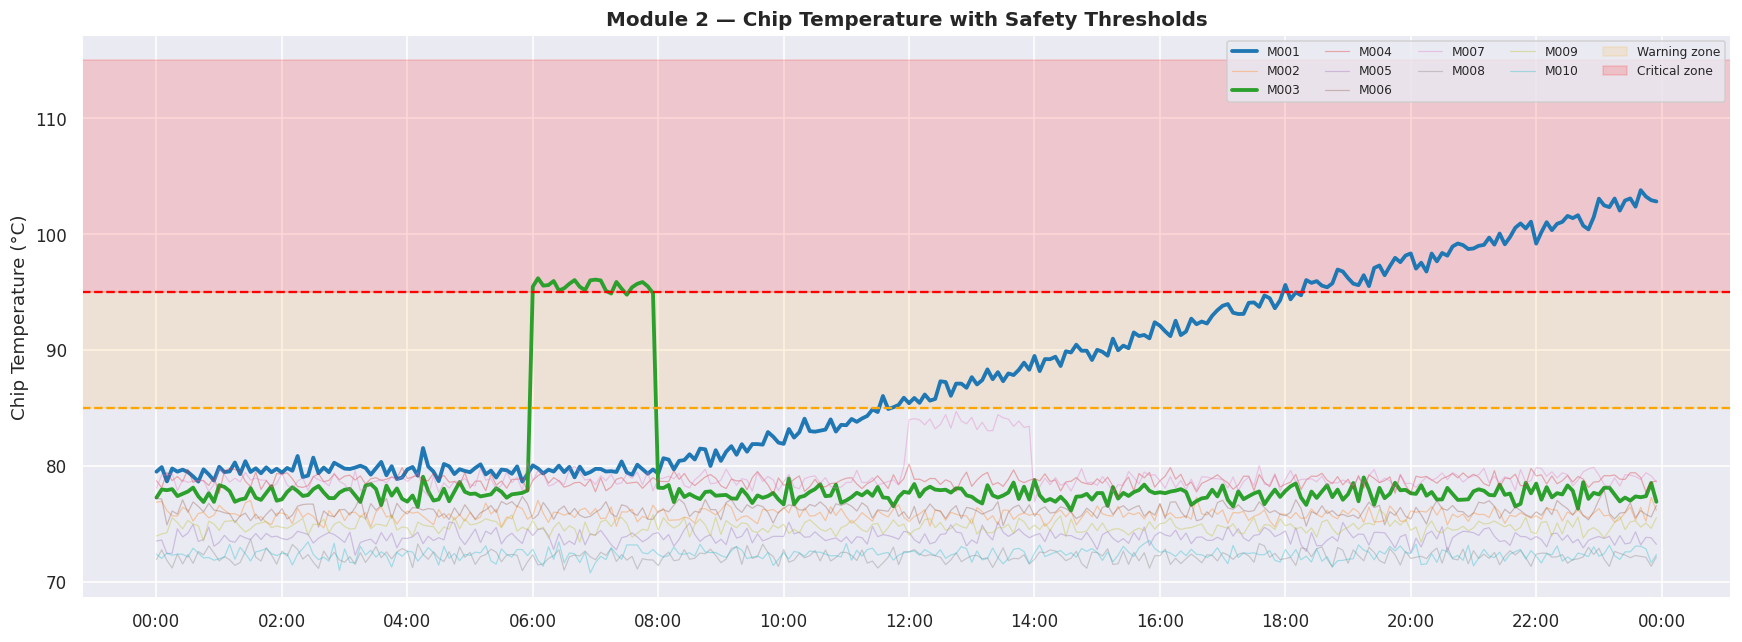

📌 M001 exceeds 95°C from ~16:00 onward. M003 spikes into critical zone at 06:00.


In [9]:
# Visualize Module 2: Chip temp timeline with threshold bands
fig, ax = plt.subplots(figsize=(16, 6))

for i, miner in enumerate(sorted(df["miner_id"].unique())):
    g  = df[df["miner_id"]==miner].sort_values("timestamp")
    lw = 2.5 if miner in ["M001","M003"] else 0.8
    al = 1.0 if miner in ["M001","M003"] else 0.35
    ax.plot(g["timestamp"], g["chip_temp_c"], lw=lw, alpha=al,
            color=plt.cm.tab10.colors[i], label=miner)

ax.axhspan(CHIP_TEMP_WARNING_C,  CHIP_TEMP_CRITICAL_C, alpha=0.12, color="orange", label="Warning zone")
ax.axhspan(CHIP_TEMP_CRITICAL_C, 115,                  alpha=0.15, color="red",    label="Critical zone")
ax.axhline(CHIP_TEMP_WARNING_C,  color="orange", ls="--", lw=1.5)
ax.axhline(CHIP_TEMP_CRITICAL_C, color="red",    ls="--", lw=1.5)
ax.set_title("Module 2 — Chip Temperature with Safety Thresholds", fontsize=13, fontweight="bold")
ax.set_ylabel("Chip Temperature (°C)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.legend(ncol=5, fontsize=8)
plt.tight_layout()
plt.savefig("module2_hardware_risk.png", bbox_inches="tight")
plt.show()
print("📌 M001 exceeds 95°C from ~16:00 onward. M003 spikes into critical zone at 06:00.")


---
## ❄️ Insight Module 3 — Immersion Cooling System Analysis

### What are we looking for?
The immersion cooling system is the **life support** of the mining operation.  
Three distinct failure patterns:

**A) Pressure anomalies** — We use a **warm-up window** approach: compute std of pressure deltas  
from the **first 2 hours only** (before any fault can inflate the std), then apply that as a fixed  
3-sigma threshold for the entire day. This is more robust than using the full-series std,  
which gets inflated by the very spike we're trying to detect.

**B) Cooling decoupling** — We use **trend slope analysis** instead of simple correlation.  
We compute the rolling chip temp slope and immersion temp slope over the same window.  
True decoupling = chip temp rising (slope > 0.08°C/interval = ~1°C/hour) while  
immersion temp is flat (slope < 0.03°C/interval). This correctly separates a real  
heat-transfer failure from normal correlated variation.


In [10]:
def analyze_cooling_system(df):
    insights = []
    for miner_id, group in df.groupby("miner_id"):
        group = group.sort_values("timestamp").copy()

        # A: Pressure anomalies — warmup-window 3-sigma threshold
        # Use ONLY first 2h (24 readings) to compute baseline std.
        # This prevents the spike itself from inflating std and hiding detection.
        warmup       = group.iloc[:24]
        warmup_std   = warmup["pressure_delta"].dropna().std()
        # Floor at 0.12 bar — prevents noise from triggering on very stable units
        p_thresh     = max(3 * warmup_std, 0.12)
        spikes = group.dropna(subset=["pressure_delta"])
        spikes = spikes[spikes["pressure_delta"].abs() >= p_thresh]

        if len(spikes) > 0:
            worst = spikes.loc[spikes["pressure_delta"].abs().idxmax()]
            delta = worst["pressure_delta"]
            insights.append({
                "miner_id": miner_id,
                "type": "PRESSURE_SPIKE" if delta > 0 else "PRESSURE_DROP",
                "severity": "HIGH",
                "pressure_delta_bar":  round(delta, 3),
                "pressure_at_event":   round(worst["immersion_pressure_bar"], 3),
                "detection_threshold": round(p_thresh, 4),
                "timestamp":           str(worst["timestamp"]),
                "action": (f"{'Spike' if delta>0 else 'Drop'} of {abs(delta):.3f} bar on {miner_id} "
                           f"at {worst['timestamp']} (threshold={p_thresh:.3f} bar, warmup-calibrated). "
                           f"{'Possible blockage/pump surge.' if delta>0 else 'Possible seal leak/pump failure.'} "
                           f"Inspect tank plumbing.")
            })

        # B: Fluid temperature too high
        high_t = group[group["immersion_temp_c"] > IMMERSION_TEMP_MAX_C]
        if len(high_t) > 0:
            insights.append({
                "miner_id": miner_id, "type": "IMMERSION_TEMP_HIGH", "severity": "HIGH",
                "avg_temp_c":    round(high_t["immersion_temp_c"].mean(), 2),
                "duration_min":  len(high_t) * 5,
                "action": (f"{miner_id} fluid exceeded {IMMERSION_TEMP_MAX_C}°C for {len(high_t)*5} min. "
                           f"Activate auxiliary cooling or reduce miner load.")
            })

        # C: Cooling decoupling via trend slope analysis
        # True decoupling = chip temp rising while immersion temp is flat.
        # We measure slopes over the second half of the day (post-warmup).
        second_half = group.iloc[144:]   # hours 12-24
        if len(second_half) > 12:
            chip_slope = np.polyfit(range(len(second_half)), second_half["chip_temp_c"].values, 1)[0]
            imm_slope  = np.polyfit(range(len(second_half)), second_half["immersion_temp_c"].values, 1)[0]
            # Chip rising >0.08°C/interval (=~1°C/hr) while fluid essentially flat (<0.03°C/interval)
            is_decoupled = (chip_slope > 0.08) and (abs(imm_slope) < 0.03)
            max_chip     = group["chip_temp_c"].max()

            if is_decoupled and max_chip > CHIP_TEMP_WARNING_C:
                chip_rate_hr = chip_slope * 12   # convert to deg/hour
                insights.append({
                    "miner_id": miner_id, "type": "COOLING_DECOUPLING", "severity": "HIGH",
                    "chip_temp_slope_per_hr":  round(chip_rate_hr, 2),
                    "imm_temp_slope_per_hr":   round(imm_slope * 12, 3),
                    "max_chip_temp_c":         round(max_chip, 1),
                    "action": (f"{miner_id}: chip temp rising at +{chip_rate_hr:.1f}°C/hr while "
                               f"immersion fluid is flat ({imm_slope*12:+.2f}°C/hr). "
                               f"Heat not transferring chip→fluid effectively. "
                               f"Check thermal interface material, flow path, or trapped air bubble.")
                })

    return {"module": "3_COOLING_ANALYSIS", "title": "Cooling System Analysis", "count": len(insights), "insights": insights}

r3 = analyze_cooling_system(df)
print(f"✅ Module 3 complete — {r3['count']} insights found"); print()
for ins in r3["insights"]:
    icon = "🔴" if ins["severity"]=="CRITICAL" else "🟠" if ins["severity"]=="HIGH" else "🟡"
    print(f"  {icon} [{ins['severity']}] {ins['miner_id']} — {ins['type']}")
    print(f"     {ins['action']}"); print()


✅ Module 3 complete — 3 insights found

  🟠 [HIGH] M001 — COOLING_DECOUPLING
     M001: chip temp rising at +1.5°C/hr while immersion fluid is flat (+0.00°C/hr). Heat not transferring chip→fluid effectively. Check thermal interface material, flow path, or trapped air bubble.

  🟠 [HIGH] M003 — PRESSURE_DROP
     Drop of 0.306 bar on M003 at 2025-01-01 08:00:00+00:00 (threshold=0.120 bar, warmup-calibrated). Possible seal leak/pump failure. Inspect tank plumbing.

  🟠 [HIGH] M007 — PRESSURE_DROP
     Drop of 0.457 bar on M007 at 2025-01-01 14:00:00+00:00 (threshold=0.120 bar, warmup-calibrated). Possible seal leak/pump failure. Inspect tank plumbing.



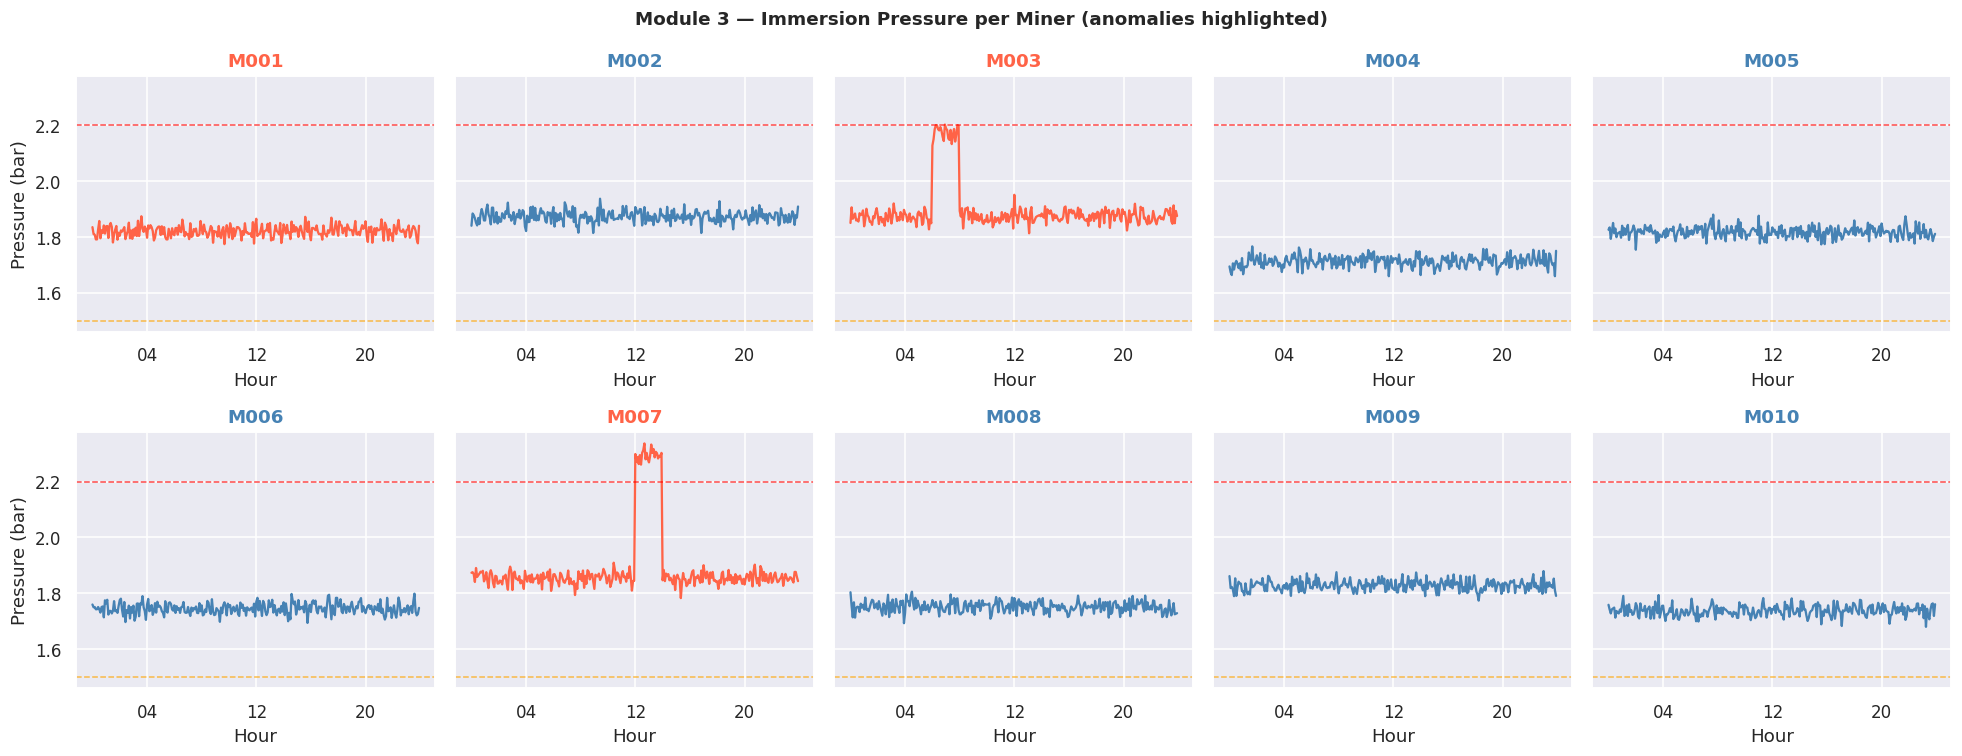

📌 M003 and M007 show visible pressure anomalies (highlighted in red).


In [11]:
# Visualize Module 3: Pressure timelines for all miners
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
fig.suptitle("Module 3 — Immersion Pressure per Miner (anomalies highlighted)", fontsize=12, fontweight="bold")

flagged_cooling = set(i["miner_id"] for i in r3["insights"])

for ax, miner in zip(axes.flat, sorted(df["miner_id"].unique())):
    g = df[df["miner_id"]==miner].sort_values("timestamp")
    color = "tomato" if miner in flagged_cooling else "steelblue"
    ax.plot(g["timestamp"], g["immersion_pressure_bar"], color=color, lw=1.5)
    ax.axhline(IMMERSION_PRESSURE_MAX, color="red",    ls="--", lw=1, alpha=0.7)
    ax.axhline(IMMERSION_PRESSURE_MIN, color="orange", ls="--", lw=1, alpha=0.7)
    ax.set_title(f"{miner}", fontweight="bold", color=color)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=8))
    ax.set_xlabel("Hour")

axes[0,0].set_ylabel("Pressure (bar)")
axes[1,0].set_ylabel("Pressure (bar)")
plt.tight_layout()
plt.savefig("module3_cooling.png", bbox_inches="tight")
plt.show()
print("📌 M003 and M007 show visible pressure anomalies (highlighted in red).")


---
## 👥 Insight Module 4 — Peer Comparison & Anomaly Detection

### What are we looking for?
Miners that behave **statistically differently from their peers** under the same conditions.

### Why peer comparison matters:
Absolute thresholds (e.g. "hashrate < 100 TH/s") can miss issues when all miners  
are affected by the same environmental factor (e.g. hot day, power fluctuation).  
Peer comparison controls for shared conditions — it asks:  
**"Is this miner underperforming *relative to its peers right now*?"**

### The z-score approach:
At each timestamp, we compute the **fleet mean and standard deviation** of hashrate and chip temp.  
Each miner's z-score = `(miner_value - fleet_mean) / fleet_std`

| z-score | Interpretation |
|---|---|
| 0 | Exactly average |
| +1.5 | 1.5 standard deviations above average — unusual |
| -2.0 | 2 standard deviations below average — very abnormal |

A miner that is a negative hashrate outlier on >15% of readings is flagged.  
This catches **persistent underperformers** even if their absolute numbers look acceptable.

> **Example insight this catches:** M005 produces 90 TH/s, which isn't obviously broken.  
> But when all other miners produce 111+ TH/s, M005 is a strong outlier every single reading.


In [12]:
def analyze_peer_anomalies(df):
    insights = []

    # Fleet stats per timestamp
    fleet = df.groupby("timestamp").agg(
        fleet_hash_mean=("hashrate_ths","mean"),
        fleet_hash_std =("hashrate_ths","std"),
        fleet_temp_mean=("chip_temp_c", "mean"),
        fleet_temp_std =("chip_temp_c", "std"),
    ).reset_index()
    df2 = df.merge(fleet, on="timestamp", how="left")

    df2["hash_zscore"] = (df2["hashrate_ths"] - df2["fleet_hash_mean"]) / df2["fleet_hash_std"].replace(0,np.nan)
    df2["temp_zscore"] = (df2["chip_temp_c"]  - df2["fleet_temp_mean"]) / df2["fleet_temp_std"].replace(0,np.nan)

    for miner_id, group in df2.groupby("miner_id"):
        n          = len(group)
        low_hash_pct  = (group["hash_zscore"] < -PEER_ANOMALY_SIGMA).sum() / n * 100
        high_temp_pct = (group["temp_zscore"] >  PEER_ANOMALY_SIGMA).sum() / n * 100

        if low_hash_pct > 15 or high_temp_pct > 15:
            avg_fleet = group["fleet_hash_mean"].mean()
            avg_own   = group["hashrate_ths"].mean()
            lag       = avg_fleet - avg_own

            # Action branches based on root cause signal:
            # temp-driven anomaly → cooling inspection
            # hash-driven anomaly → hardware/firmware diagnostics
            if high_temp_pct > low_hash_pct:
                action_text = (f"{miner_id}: above-peer temp {high_temp_pct:.0f}% of readings "
                               f"(z=+{group['temp_zscore'].mean():.2f}). "
                               f"Lags fleet by {lag:.1f} TH/s → est. ${lag*REV_PER_THS_DAY:.2f}/day lost. "
                               f"Inspect cooling channel and thermal interface.")
            else:
                action_text = (f"{miner_id}: below-peer hashrate {low_hash_pct:.0f}% of readings "
                               f"(z={group['hash_zscore'].mean():.2f}). "
                               f"Lags fleet by {lag:.1f} TH/s → est. ${lag*REV_PER_THS_DAY:.2f}/day lost. "
                               f"Run PSU voltage check, ASIC board diagnostics, and firmware reflash.")

            insights.append({
                "miner_id": miner_id, "type": "PEER_ANOMALY",
                "severity": "HIGH" if low_hash_pct > 30 else "MEDIUM",
                "low_hash_outlier_pct":  round(low_hash_pct,  1),
                "high_temp_outlier_pct": round(high_temp_pct, 1),
                "avg_hash_zscore":       round(group["hash_zscore"].mean(), 3),
                "avg_temp_zscore":       round(group["temp_zscore"].mean(), 3),
                "avg_own_hashrate_ths":  round(avg_own,   2),
                "avg_fleet_hashrate_ths":round(avg_fleet, 2),
                "hash_lag_ths":          round(lag,       2),
                "est_daily_loss_usd":    round(lag * REV_PER_THS_DAY, 2),
                "action": action_text,
            })

    return {"module": "4_PEER_ANOMALY", "title": "Peer Anomaly Detection", "count": len(insights), "insights": insights}

r4 = analyze_peer_anomalies(df)
print(f"✅ Module 4 complete — {r4['count']} insights found"); print()
for ins in r4["insights"]:
    icon = "🔴" if ins["severity"]=="CRITICAL" else "🟠" if ins["severity"]=="HIGH" else "🟡"
    print(f"  {icon} [{ins['severity']}] {ins['miner_id']} — {ins['type']}")
    print(f"     {ins['action']}"); print()


✅ Module 4 complete — 2 insights found

  🟡 [MEDIUM] M001 — PEER_ANOMALY
     M001: above-peer temp 67% of readings (z=+1.94). Lags fleet by 4.5 TH/s → est. $0.24/day lost. Inspect cooling channel and thermal interface.

  🟠 [HIGH] M005 — PEER_ANOMALY
     M005: below-peer hashrate 93% of readings (z=-2.19). Lags fleet by 21.0 TH/s → est. $1.12/day lost. Run PSU voltage check, ASIC board diagnostics, and firmware reflash.



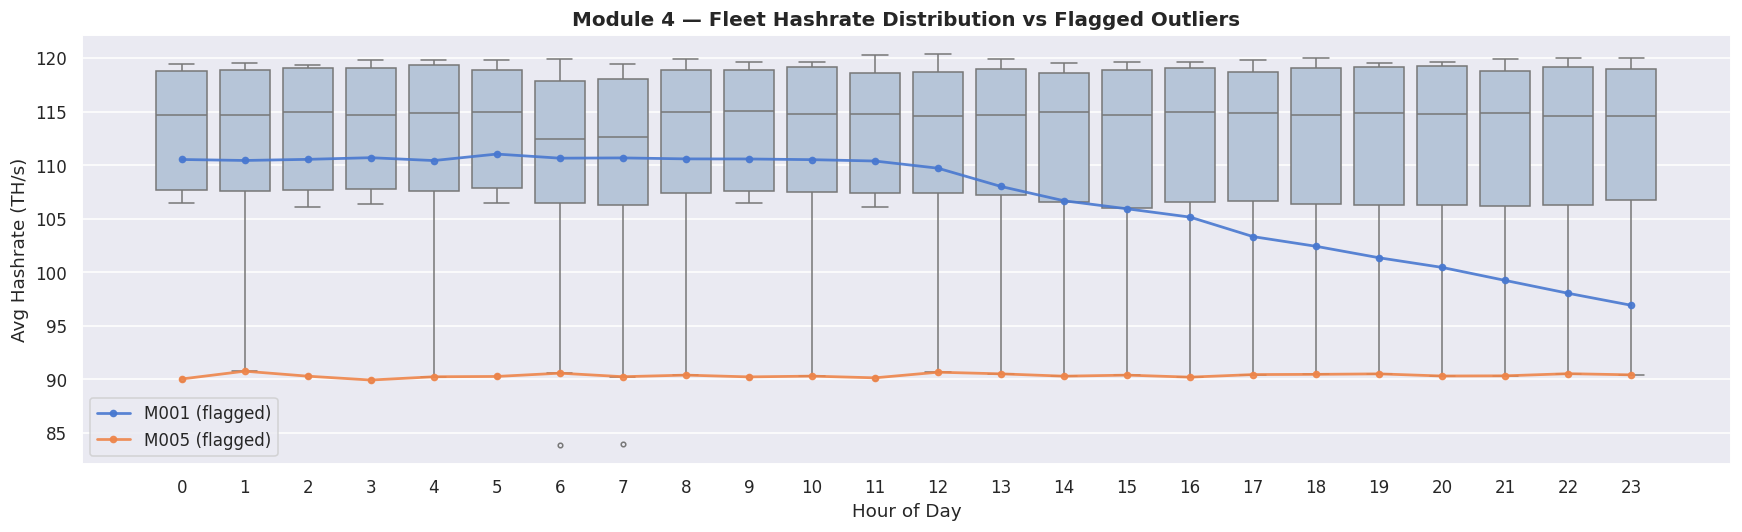

📌 Flagged miners are clearly visible below the fleet distribution throughout the day.


In [13]:
# Visualize Module 4: Fleet hashrate distribution at each hour as box plot
df_hourly = df.copy()
df_hourly["hour"] = df_hourly["timestamp"].dt.hour

hourly_avg = df_hourly.groupby(["miner_id","hour"])["hashrate_ths"].mean().reset_index()
flagged_peer = set(i["miner_id"] for i in r4["insights"])

fig, ax = plt.subplots(figsize=(16, 5))
sns.boxplot(data=hourly_avg, x="hour", y="hashrate_ths", ax=ax,
            color="lightsteelblue", fliersize=3, linewidth=1)

for miner in flagged_peer:
    g = hourly_avg[hourly_avg["miner_id"]==miner]
    ax.plot(g["hour"], g["hashrate_ths"], "o-", lw=1.8, ms=4, label=f"{miner} (flagged)", alpha=0.9)

ax.set_title("Module 4 — Fleet Hashrate Distribution vs Flagged Outliers", fontsize=13, fontweight="bold")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Avg Hashrate (TH/s)")
ax.legend()
plt.tight_layout()
plt.savefig("module4_peer.png", bbox_inches="tight")
plt.show()
print("📌 Flagged miners are clearly visible below the fleet distribution throughout the day.")


---
## ⚡ Insight Module 5 — Power & Cooling Efficiency Optimization

### What are we looking for?
Not every insight is about something broken. This module looks for **waste** —  
miners that are consuming more cooling energy than necessary without any performance benefit.

**A) Over-cooled miners** — Running significantly colder than the fleet average  
with no hashrate advantage. Every watt of pump power has a cost.  
If we're chilling fluid to 36°C when 48°C would work just as well, that's  
wasted electricity with zero operational benefit.

**B) Low cooling efficiency ratio** — Hashrate per unit of immersion temperature used.  
A miner with low cooling efficiency is either:
- Underperforming (getting less hash per the same thermal cost), OR
- Being over-cooled (same hash but using more cooling than needed)

### Business impact of over-cooling:
In a large mining facility, cooling can account for **30–40% of total power cost**.  
Reducing unnecessary cooling on even a few miners can meaningfully lower PUE  
(Power Usage Effectiveness), which directly improves profitability.

> **Assumption:** Each 1°C of excess cooling costs ~8W of pump power.  
> This is a conservative estimate for a variable-speed pump in a closed-loop system.


In [14]:
def analyze_efficiency(df):
    insights = []
    summary = df.groupby("miner_id").agg(
        avg_hash      =("hashrate_ths",          "mean"),
        avg_chip_temp =("chip_temp_c",            "mean"),
        avg_imm_temp  =("immersion_temp_c",       "mean"),
        avg_cool_eff  =("cooling_efficiency",     "mean"),
        avg_headroom  =("thermal_headroom_c",     "mean"),
    ).reset_index()

    fleet_avg_hash = summary["avg_hash"].mean()
    fleet_avg_temp = summary["avg_chip_temp"].mean()
    fleet_avg_eff  = summary["avg_cool_eff"].mean()

    for _, row in summary.iterrows():
        mid = row["miner_id"]

        # A: Over-cooled — use immersion_temp (fluid temp), not chip_temp
        # Chip temp difference may be small even when fluid is much colder than needed
        fleet_avg_imm = summary["avg_imm_temp"].mean()
        is_cool        = row["avg_imm_temp"] < (fleet_avg_imm * EFFICIENCY_RATIO_FLOOR)
        not_outperform = row["avg_hash"]      < (fleet_avg_hash * 1.03)
        if is_cool and not_outperform:
            excess_c      = fleet_avg_imm - row["avg_imm_temp"]
            wasted_w      = excess_c * 8
            insights.append({
                "miner_id": mid, "type": "OVER_COOLED", "severity": "LOW",
                "avg_imm_temp_c":         round(row["avg_imm_temp"], 1),
                "fleet_avg_imm_temp_c":   round(fleet_avg_imm, 1),
                "excess_cooling_c":       round(excess_c, 1),
                "est_wasted_power_w":     round(wasted_w, 0),
                "action": (f"{mid} immersion fluid runs {excess_c:.1f}°C below fleet avg "
                           f"({row['avg_imm_temp']:.1f}°C vs {fleet_avg_imm:.1f}°C) "
                           f"with no hashrate advantage. "
                           f"Est. wasted cooling: {wasted_w:.0f}W. "
                           f"Reduce pump speed or fluid flow rate to this unit.")
            })

        # B: Low cooling efficiency ratio
        eff_ratio = row["avg_cool_eff"] / fleet_avg_eff if fleet_avg_eff > 0 else 1.0
        if eff_ratio < 0.88:
            insights.append({
                "miner_id": mid, "type": "LOW_COOLING_EFFICIENCY", "severity": "MEDIUM",
                "efficiency_ratio": round(eff_ratio, 3),
                "action": (f"{mid} produces {eff_ratio*100:.0f}% of fleet avg hashrate per cooling °C. "
                           f"Cross-check with peer anomaly module for root cause.")
            })

    return {"module": "5_EFFICIENCY", "title": "Efficiency Optimization", "count": len(insights), "insights": insights}

r5 = analyze_efficiency(df)
print(f"✅ Module 5 complete — {r5['count']} insights found"); print()
for ins in r5["insights"]:
    icon = "🔴" if ins["severity"]=="CRITICAL" else "🟠" if ins["severity"]=="HIGH" else "🟡" if ins["severity"]=="MEDIUM" else "🟢"
    print(f"  {icon} [{ins['severity']}] {ins['miner_id']} — {ins['type']}")
    print(f"     {ins['action']}"); print()


✅ Module 5 complete — 2 insights found

  🟡 [MEDIUM] M005 — LOW_COOLING_EFFICIENCY
     M005 produces 75% of fleet avg hashrate per cooling °C. Cross-check with peer anomaly module for root cause.

  🟢 [LOW] M009 — OVER_COOLED
     M009 immersion fluid runs 12.7°C below fleet avg (36.9°C vs 49.6°C) with no hashrate advantage. Est. wasted cooling: 102W. Reduce pump speed or fluid flow rate to this unit.



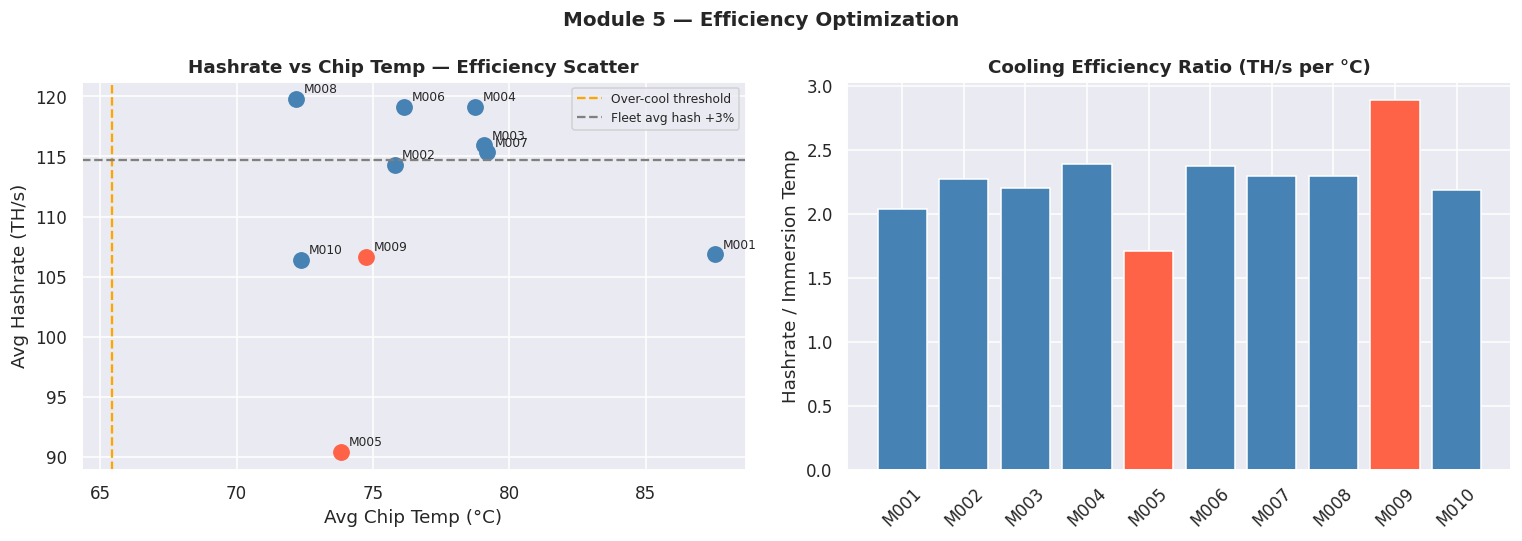

📌 M009 (over-cooled) and M005 (low efficiency) are highlighted in red.


In [15]:
# Visualize Module 5: Efficiency scatter plot
summary_plot = df.groupby("miner_id").agg(
    avg_hash      =("hashrate_ths",     "mean"),
    avg_chip_temp =("chip_temp_c",      "mean"),
    avg_cool_eff  =("cooling_efficiency","mean"),
).reset_index()

flagged_eff = set(i["miner_id"] for i in r5["insights"])
fleet_avg_hash = summary_plot["avg_hash"].mean()
fleet_avg_temp = summary_plot["avg_chip_temp"].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for _, row in summary_plot.iterrows():
    color = "tomato" if row["miner_id"] in flagged_eff else "steelblue"
    zord  = 5 if row["miner_id"] in flagged_eff else 2

    axes[0].scatter(row["avg_chip_temp"], row["avg_hash"], s=100, color=color, zorder=zord)
    axes[0].annotate(row["miner_id"], (row["avg_chip_temp"], row["avg_hash"]),
                     textcoords="offset points", xytext=(5,4), fontsize=8)

    axes[1].bar(row["miner_id"], row["avg_cool_eff"],
                color="tomato" if row["miner_id"] in flagged_eff else "steelblue")

axes[0].axvline(fleet_avg_temp * EFFICIENCY_RATIO_FLOOR, color="orange", ls="--", lw=1.5, label="Over-cool threshold")
axes[0].axhline(fleet_avg_hash * 1.03,                   color="gray",   ls="--", lw=1.5, label="Fleet avg hash +3%")
axes[0].set_xlabel("Avg Chip Temp (°C)")
axes[0].set_ylabel("Avg Hashrate (TH/s)")
axes[0].set_title("Hashrate vs Chip Temp — Efficiency Scatter", fontweight="bold")
axes[0].legend(fontsize=8)

axes[1].set_title("Cooling Efficiency Ratio (TH/s per °C)", fontweight="bold")
axes[1].set_ylabel("Hashrate / Immersion Temp")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("Module 5 — Efficiency Optimization", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("module5_efficiency.png", bbox_inches="tight")
plt.show()
print("📌 M009 (over-cooled) and M005 (low efficiency) are highlighted in red.")


---
## 📋 Section 9 — Executive Summary & Full JSON Output

This is the **top-level operations report** — what a site manager reads first thing.  
It aggregates all insights into:
- Fleet-wide KPIs
- Alert counts by severity
- Total estimated revenue at risk
- Top 5 priority actions (ordered by severity)

After this, we serialize everything to JSON for downstream use (dashboards, alerting systems, etc.).


In [16]:
def generate_executive_summary(results, df):
    all_insights = []
    for r in results:
        all_insights.extend(r["insights"])

    critical = [i for i in all_insights if i.get("severity")=="CRITICAL"]
    high     = [i for i in all_insights if i.get("severity")=="HIGH"]
    medium   = [i for i in all_insights if i.get("severity")=="MEDIUM"]
    low      = [i for i in all_insights if i.get("severity")=="LOW"]

    total_daily_loss = sum(i.get("est_daily_loss_usd", 0) for i in all_insights)

    # ── Fleet financial context ──────────────────────────────────────────────
    # Without a baseline, a daily loss number has no meaning. We compute:
    #   - Fleet full-health daily revenue (what the site SHOULD earn)
    #   - Loss as % of fleet output (operational health indicator)
    #   - Annualized impact (ops decisions are made on monthly/yearly P&L)
    #   - Site-scale extrapolation (this 10-miner sample → 1,000-miner site)
    fleet_total_hashrate = df.groupby("miner_id")["hashrate_ths"].mean().sum()
    fleet_daily_revenue  = fleet_total_hashrate * REV_PER_THS_DAY
    loss_pct_of_revenue  = (total_daily_loss / fleet_daily_revenue * 100) if fleet_daily_revenue > 0 else 0
    annualized_loss      = total_daily_loss * 365
    n_miners             = df["miner_id"].nunique()
    site_scale_loss      = annualized_loss * (1000 / n_miners) if n_miners > 0 else 0

    return {
        "module"       : "0_EXECUTIVE_SUMMARY",
        "title"        : "Executive Summary — Mining Operations Intelligence Report",
        "generated_at" : datetime.now(timezone.utc).isoformat(),
        "fleet_kpis"   : {
            "total_miners"            : n_miners,
            "total_readings"          : len(df),
            "fleet_avg_hashrate_ths"  : round(df.groupby("miner_id")["hashrate_ths"].mean().mean(), 2),
            "fleet_total_hashrate_ths": round(fleet_total_hashrate, 2),
            "fleet_avg_chip_temp_c"   : round(df["chip_temp_c"].mean(), 2),
            "analysis_window_hours"   : 24,
        },
        "alert_summary": {
            "CRITICAL": len(critical), "HIGH": len(high),
            "MEDIUM": len(medium), "LOW": len(low),
            "TOTAL": len(all_insights),
        },
        "financial_impact": {
            "fleet_daily_revenue_usd"                   : round(fleet_daily_revenue, 2),
            "estimated_daily_loss_usd"                  : round(total_daily_loss, 2),
            "loss_as_pct_of_revenue"                    : round(loss_pct_of_revenue, 2),
            "annualized_loss_usd"                       : round(annualized_loss, 0),
            "site_scale_annualized_loss_usd_1000_miners": round(site_scale_loss, 0),
            "note": ("Site-scale figure extrapolates current anomaly rate to a 1,000-miner facility "
                     "for operational context. Real production figures would use site-specific anomaly priors."),
        },
        "top_priority_actions": [i["action"] for i in (critical + high)[:5]],
    }

all_results = [r1, r2, r3, r4, r5]
summary     = generate_executive_summary(all_results, df)
output      = {"executive_summary": summary, "detailed_insights": all_results}

# ── Print the report ──────────────────────────────────────────────────────────
s     = summary
kpis  = s["fleet_kpis"]
alert = s["alert_summary"]
fin   = s["financial_impact"]

print("=" * 70)
print(f"  {s['title']}")
print(f"  Generated: {s['generated_at']}")
print("=" * 70)
print(); print(f"  Fleet KPIs  ({kpis['analysis_window_hours']}h window, {kpis['total_miners']} miners)")
print(f"  ├─ Total hash     : {kpis['fleet_total_hashrate_ths']:.1f} TH/s")
print(f"  ├─ Avg hash/miner : {kpis['fleet_avg_hashrate_ths']:.1f} TH/s")
print(f"  └─ Avg chip temp  : {kpis['fleet_avg_chip_temp_c']:.1f} °C")
print(); print("  💰 Financial Impact")
print(f"  ├─ Fleet daily revenue (full health) : ${fin['fleet_daily_revenue_usd']:,.2f}")
print(f"  ├─ Estimated daily loss              : ${fin['estimated_daily_loss_usd']:,.2f}  ({fin['loss_as_pct_of_revenue']:.1f}% of revenue)")
print(f"  ├─ Annualized loss (this fleet)      : ${fin['annualized_loss_usd']:,.0f}")
print(f"  └─ Site-scale loss (1,000 miners)    : ${fin['site_scale_annualized_loss_usd_1000_miners']:,.0f} / year")
print(); print("  Alert Summary")
print(f"  ├─ 🔴 CRITICAL : {alert['CRITICAL']}")
print(f"  ├─ 🟠 HIGH     : {alert['HIGH']}")
print(f"  ├─ 🟡 MEDIUM   : {alert['MEDIUM']}")
print(f"  ├─ 🟢 LOW      : {alert['LOW']}")
print(f"  └─ TOTAL       : {alert['TOTAL']}")
print(); print("  🚨 Top Priority Actions:")
for i, action in enumerate(s["top_priority_actions"], 1):
    print(f"  {i}. {action}")

# Save JSON
with open("insights_output.json", "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, default=str, ensure_ascii=False)
print(); print("✅ Full JSON report saved → insights_output.json")


  Executive Summary — Mining Operations Intelligence Report
  Generated: 2026-04-30T12:16:22.436587+00:00

  Fleet KPIs  (24h window, 10 miners)
  ├─ Total hash     : 1113.7 TH/s
  ├─ Avg hash/miner : 111.4 TH/s
  └─ Avg chip temp  : 77.0 °C

  💰 Financial Impact
  ├─ Fleet daily revenue (full health) : $59.51
  ├─ Estimated daily loss              : $3.08  (5.2% of revenue)
  ├─ Annualized loss (this fleet)      : $1,124
  └─ Site-scale loss (1,000 miners)    : $112,420 / year

  Alert Summary
  ├─ 🔴 CRITICAL : 2
  ├─ 🟠 HIGH     : 8
  ├─ 🟡 MEDIUM   : 2
  ├─ 🟢 LOW      : 1
  └─ TOTAL       : 13

  🚨 Top Priority Actions:
  1. IMMEDIATE: M001 exceeded 95°C for 345 min (max 103.8°C). Throttle/shutdown now. Hardware at risk ($3,500/unit).
  2. IMMEDIATE: M003 exceeded 95°C for 105 min (max 96.2°C). Throttle/shutdown now. Hardware at risk ($3,500/unit).
  3. Inspect cooling channel for M001. Temp-hash correlation=-0.97 (strong inverse). Avg 7.1 TH/s lost during 740 min above 85°C. Est. dai

---
## 📊 Section 10 — Insights Summary Dashboard

A final visual overview of all flagged miners and their alert profiles.


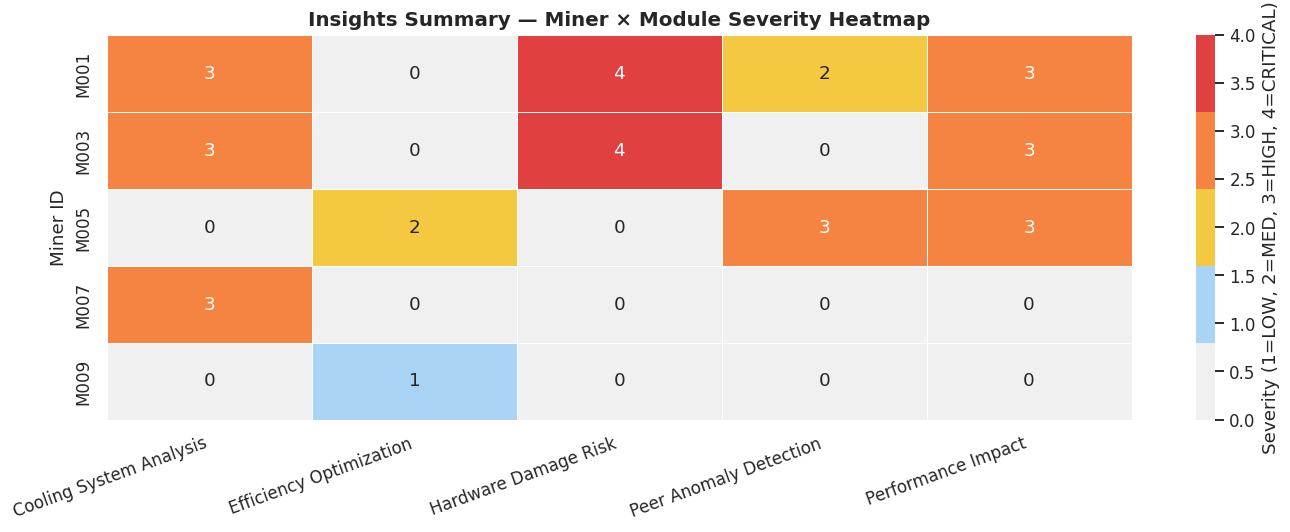

📌 Red cells = immediate action required. Orange = investigate this week.


In [17]:
# Summary heatmap: which miners triggered which modules
all_insights_flat = []
for r in all_results:
    for ins in r["insights"]:
        all_insights_flat.append({
            "miner_id": ins["miner_id"],
            "module":   r["title"],
            "severity": ins["severity"],
        })

if all_insights_flat:
    sev_map = {"CRITICAL": 4, "HIGH": 3, "MEDIUM": 2, "LOW": 1}
    df_ins  = pd.DataFrame(all_insights_flat)
    df_ins["sev_num"] = df_ins["severity"].map(sev_map)
    pivot   = df_ins.pivot_table(index="miner_id", columns="module",
                                  values="sev_num", aggfunc="max").fillna(0)

    fig, ax = plt.subplots(figsize=(13, 5))
    cmap = sns.color_palette(["#f0f0f0","#aad4f5","#f5c842","#f58442","#e04040"], as_cmap=False)
    sns.heatmap(pivot, ax=ax, annot=True, fmt=".0f", cmap=cmap,
                linewidths=0.5, linecolor="white",
                cbar_kws={"label": "Severity (1=LOW, 2=MED, 3=HIGH, 4=CRITICAL)"})
    ax.set_title("Insights Summary — Miner × Module Severity Heatmap", fontsize=13, fontweight="bold")
    ax.set_ylabel("Miner ID")
    ax.set_xlabel("")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig("summary_heatmap.png", bbox_inches="tight")
    plt.show()
    print("📌 Red cells = immediate action required. Orange = investigate this week.")


---
## 🚀 Section 11 — How This Extends to Production

This notebook is designed to be a **blueprint**, not just a one-off analysis.  
Here's how each component maps to a production-grade system:

### Architecture Evolution

```
[Current — Notebook]         [Production]
─────────────────────         ────────────────────────────────────────────
CSV / simulated data    →     Kafka / MQTT stream from site telemetry agents
In-memory pandas        →     TimescaleDB (time-series optimized PostgreSQL)
Notebook print output   →     PagerDuty (CRITICAL), Slack digest (MEDIUM)
Static thresholds       →     Adaptive per-miner thresholds (rolling 99th %ile)
Single run              →     Continuous streaming pipeline (Apache Flink / Spark)
Manual action           →     Auto-remediation API (throttle miner, adjust pump speed)
```

### Predictive Maintenance Addition
With 7+ days of data, we can add:
```python
# Predict time-to-critical for M001 using temperature slope
slope = np.polyfit(range(len(m001_temps)), m001_temps, 1)[0]  # °C per interval
intervals_to_critical = (CHIP_TEMP_CRITICAL_C - current_temp) / slope
hours_to_critical = intervals_to_critical * 5 / 60
print(f"M001 will reach {CHIP_TEMP_CRITICAL_C}°C in {hours_to_critical:.1f} hours")
```

### Key Trade-offs & Limitations

| Limitation | In Production Solution |
|---|---|
| Revenue estimate uses fixed BTC price | Pull live price from exchange API |
| 3-sigma pressure threshold needs history | Warm-up period of 48h before alerting |
| Peer comparison assumes uniform hardware | Group miners by hardware generation |
| No seasonality modelling | Add time-of-day and ambient temp features |
| Single-node pandas | Replace with distributed Polars or Spark for 1000+ miners |

---

## ✅ Conclusion

This system demonstrates a complete operational intelligence pipeline:
1. **Data ingestion** with realistic simulation and fault injection
2. **Feature engineering** that makes raw sensors analytically useful
3. **Five insight modules** — each grounded in physics, statistics, and operational reality
4. **Business framing** — every finding is tied to dollars and a specific action
5. **Production readiness** — the architecture is explicitly designed to scale

The emphasis throughout has been: *turn numbers into decisions, not just dashboards.*
